In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

In [2]:
train = pd.read_csv("train_data.csv")

In [3]:
X = train.iloc[:, :-1]
Y = train.iloc[:,-1]

In [4]:
X.shape

(54808, 13)

In [5]:
X.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [7]:
X.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
employee_id,54808.0,NaN,NaN,NaN,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
department,54808,9,Sales & Marketing,16840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,54808,34,region_2,12343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,52399,3,Bachelor's,36669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,54808,2,m,38496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recruitment_channel,54808,3,other,30446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_trainings,54808.0,NaN,NaN,NaN,1.253011,0.609264,1.0,1.0,1.0,1.0,10.0
age,54808.0,NaN,NaN,NaN,34.803915,7.660169,20.0,29.0,33.0,39.0,60.0
previous_year_rating,50684.0,NaN,NaN,NaN,3.329256,1.259993,1.0,3.0,3.0,4.0,5.0
length_of_service,54808.0,NaN,NaN,NaN,5.865512,4.265094,1.0,3.0,5.0,7.0,37.0


In [8]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,54808.0,39195.830627,22586.581449,1.0,19669.75,39225.5,58730.5,78298.0
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.00,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.00,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.00,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.00,5.0,7.0,37.0
KPIs_met >80%,54808.0,0.351974,0.477590,0.0,0.00,0.0,1.0,1.0
awards_won?,54808.0,0.023172,0.150450,0.0,0.00,0.0,0.0,1.0
avg_training_score,54808.0,63.386750,13.371559,39.0,51.00,60.0,76.0,99.0


In [ ]:
X.isnull().sum().sort_values(ascending=False)   

previous_year_rating    4124
education               2409
employee_id                0
region                     0
department                 0
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

Checking whether missing values in previous_year_rating is because they are new employees

In [6]:
missing_rating = X[X["previous_year_rating"].isna()]

print("\nMissing ratings where length_of_service <= 1:")
print((missing_rating["length_of_service"] <= 1).sum())


Missing ratings where length_of_service <= 1:
4124


So yes they are new employees which means these missing values should be filled with 0.

In [10]:
Y.value_counts()

is_promoted
0    50140
1     4668
Name: count, dtype: int64

This means dataset is highly imbalanced.So we may use SMOTENC for tree models and class weights for catboost model

In [11]:
Y.shape

(54808,)

For each categorical column check which value has what promotion rate

C:\Users\HP\AppData\Local\Temp\ipykernel_23244\675425033.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


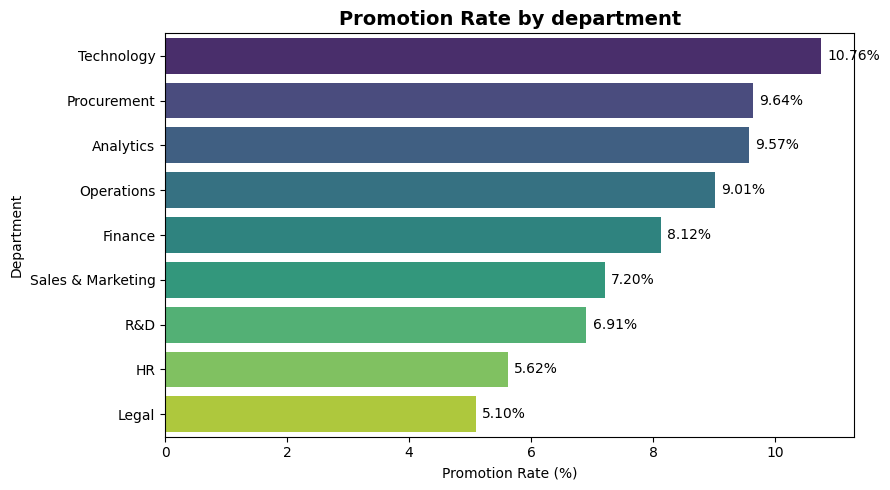

C:\Users\HP\AppData\Local\Temp\ipykernel_23244\675425033.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


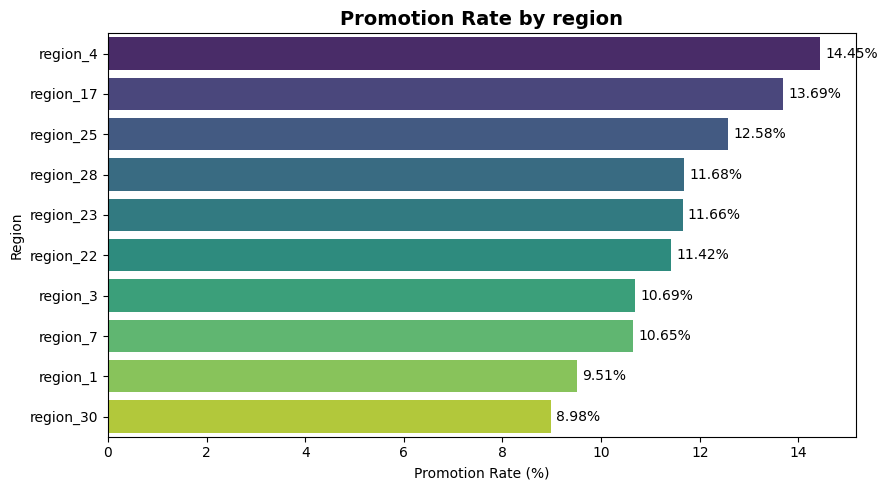

C:\Users\HP\AppData\Local\Temp\ipykernel_23244\675425033.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


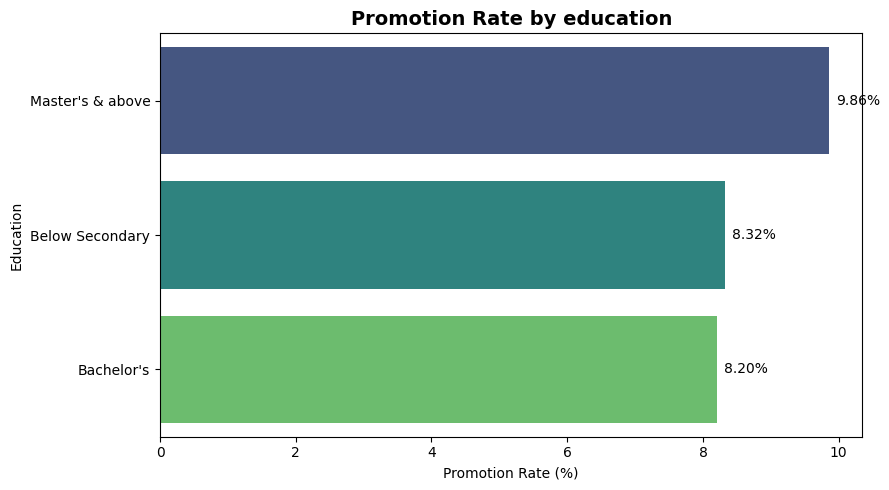

C:\Users\HP\AppData\Local\Temp\ipykernel_23244\675425033.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


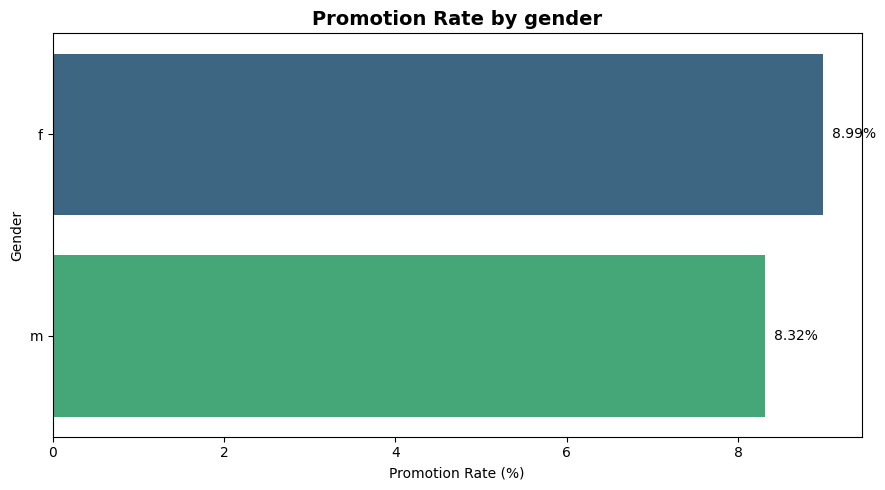

C:\Users\HP\AppData\Local\Temp\ipykernel_23244\675425033.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


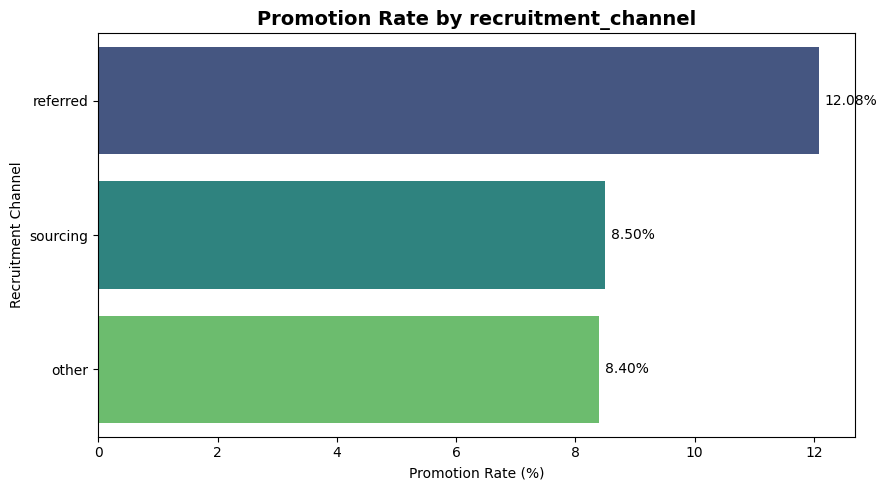

In [ ]:
cat_cols = [
    'department',
    'region',
    'education',
    'gender',
    'recruitment_channel'
]

for c in cat_cols:

    # Promotion rate for each category
    promotion_rate = (
        train.groupby(c)['is_promoted']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    # Plot
    plt.figure(figsize=(9, 5))

    sns.barplot(
        x=promotion_rate.values * 100,
        y=promotion_rate.index,
        palette="viridis"
    )

    plt.title(f'Promotion Rate by {c}', fontsize=14, fontweight='bold')
    plt.xlabel('Promotion Rate (%)')
    plt.ylabel(c.replace('_', ' ').title())

    # Add percentage values on bars
    for i, value in enumerate(promotion_rate.values * 100):
        plt.text(
            value + 0.1,
            i,
            f'{value:.2f}%',
            va='center',
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

For each binary column check which value has what promotion rate

These binary columns are kind of categorical columns.

C:\Users\HP\AppData\Local\Temp\ipykernel_23244\524180857.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


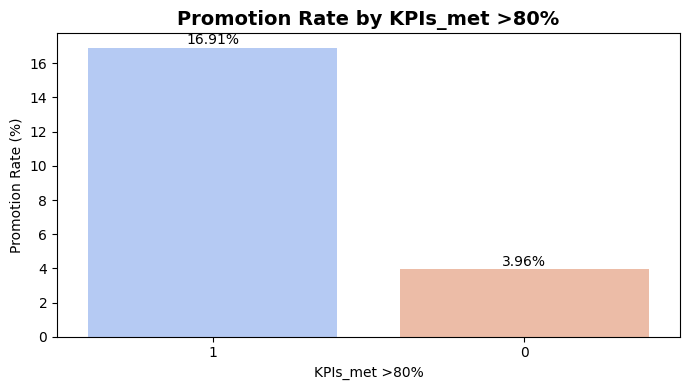

C:\Users\HP\AppData\Local\Temp\ipykernel_23244\524180857.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


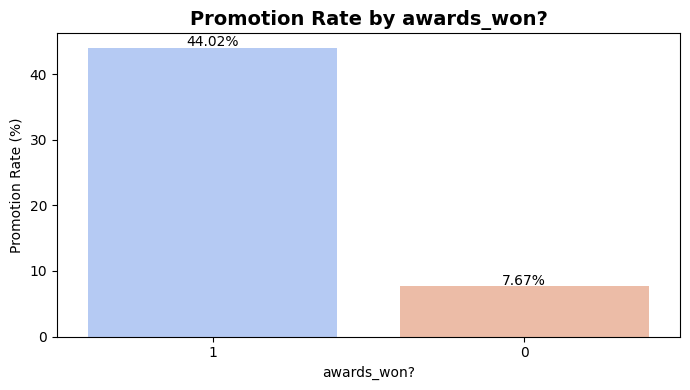

In [11]:

bin_cols = ['KPIs_met >80%', 'awards_won?']

for b in bin_cols:

    # Promotion rate for each binary value
    promotion_rate = (
        train.groupby(b)['is_promoted']
        .mean()
        .sort_values(ascending=False)
    )

    # Plot
    plt.figure(figsize=(7, 4))

    sns.barplot(
        x=promotion_rate.index.astype(str),
        y=promotion_rate.values * 100,
        palette="coolwarm"
    )

    plt.title(f'Promotion Rate by {b}', fontsize=14, fontweight='bold')
    plt.xlabel(b)
    plt.ylabel('Promotion Rate (%)')

    # Add percentage labels
    for i, value in enumerate(promotion_rate.values * 100):
        plt.text(
            i,
            value + 0.2,
            f'{value:.2f}%',
            ha='center',
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

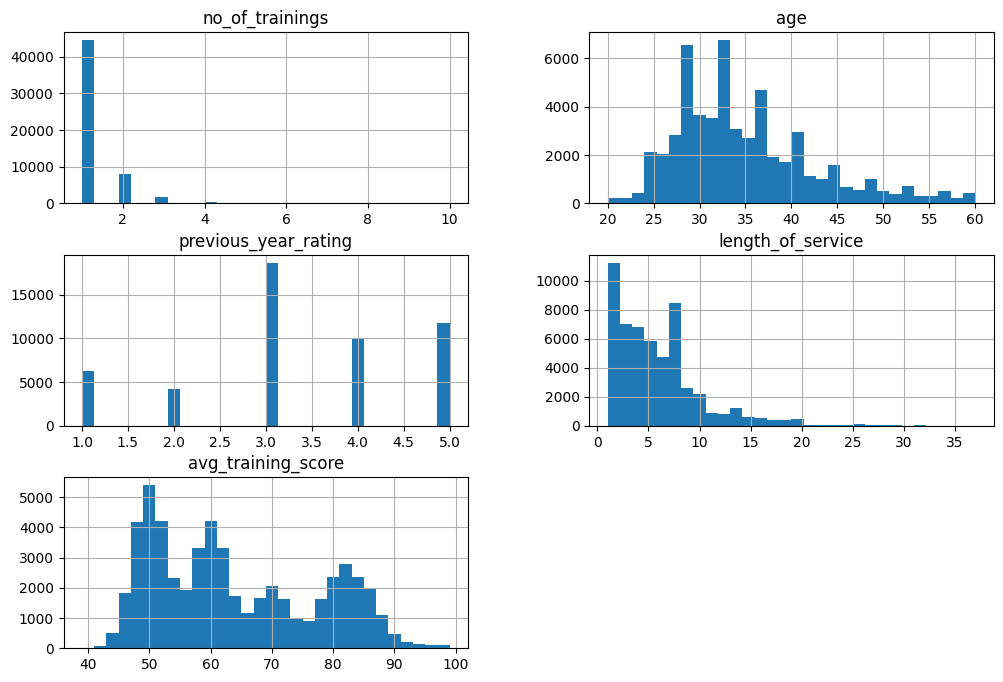

In [12]:
num_cols = ['no_of_trainings','age','previous_year_rating','length_of_service','avg_training_score']
X[num_cols].hist(bins=30,figsize=(12,8))
plt.show()
# for n in num_cols:
#     sns.boxplot(x=X[n])
#     plt.title(n)
#     plt.show()

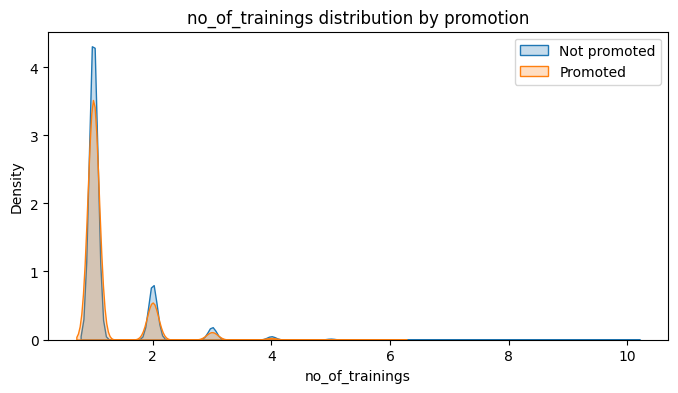

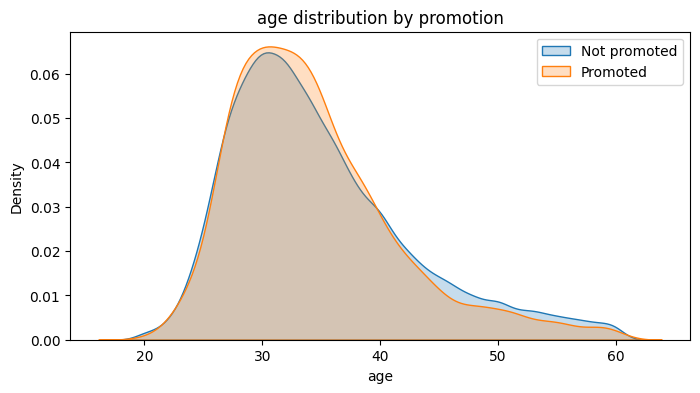

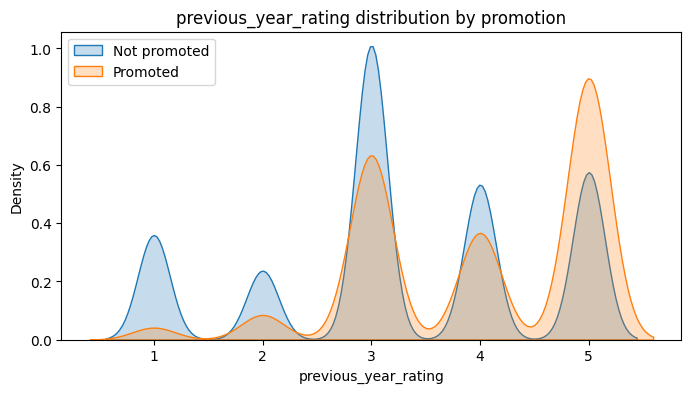

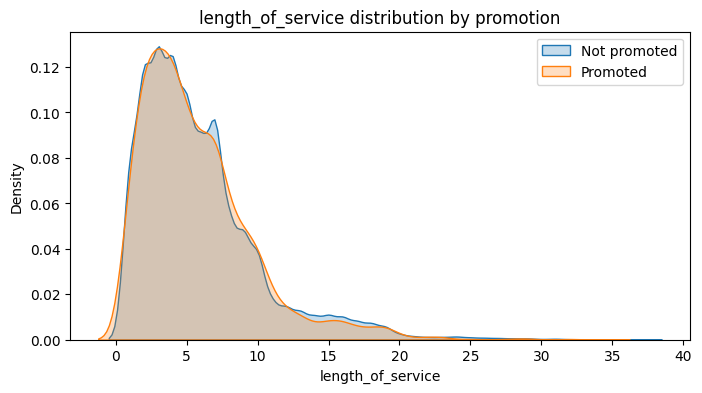

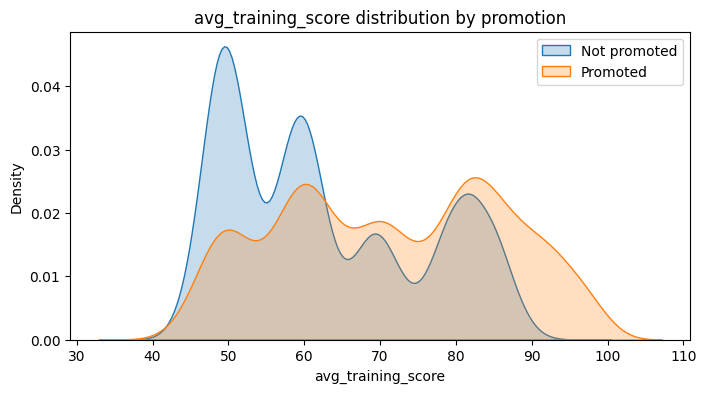

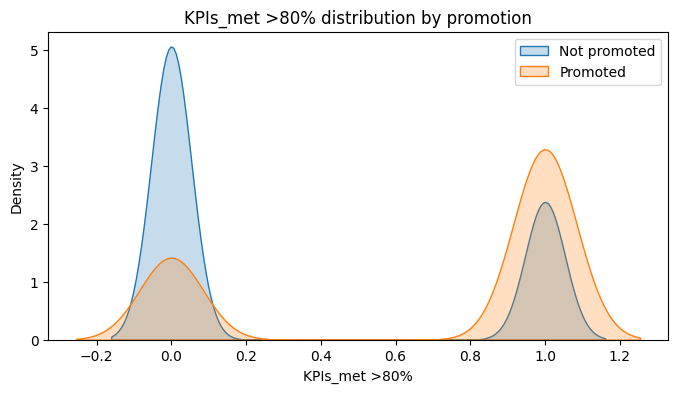

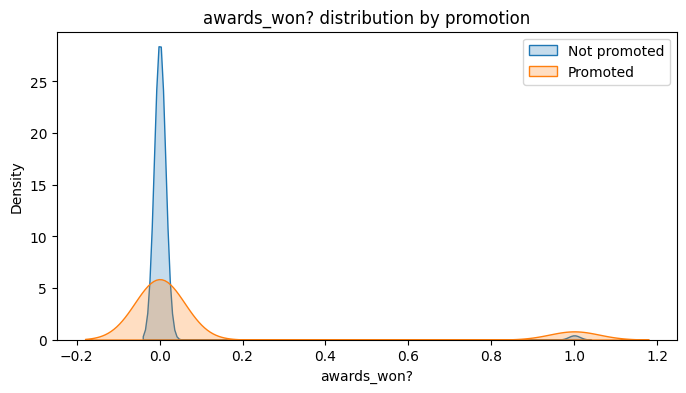

In [14]:
for c in num_cols + bin_cols :
    plt.figure(figsize=(8,4))
    sns.kdeplot(train.loc[train['is_promoted']==0, c], label='Not promoted', fill=True)
    sns.kdeplot(train.loc[train['is_promoted']==1, c], label='Promoted', fill=True)
    plt.title(f'{c} distribution by promotion')
    plt.legend()
    plt.show()


some features seem to be less important from kde plots but i will not remove them initially because maybe those features when combined with other features might have some important pattern

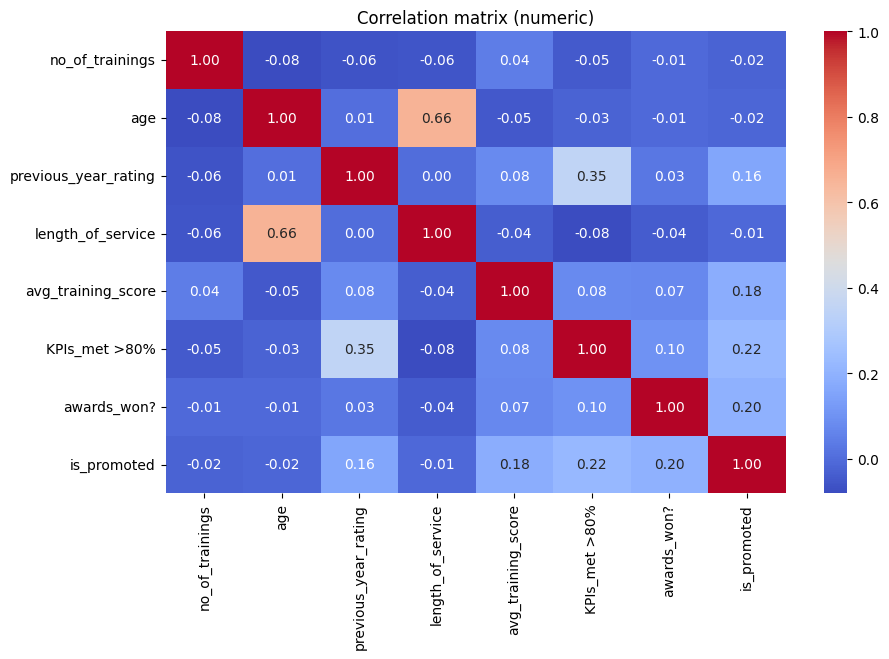

In [18]:
corr = train[num_cols + bin_cols + ['is_promoted']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix (numeric)')
plt.show()

There is no strong  linear coorelation.

Missing Values

In [ ]:
X['previous_year_rating'].value_counts(dropna=False)

previous_year_rating
3.0    18618
5.0    11741
4.0     9877
1.0     6223
2.0     4225
NaN     4124
Name: count, dtype: int64

In [22]:
X['education'].value_counts(dropna=False)

education
Bachelor's          36669
Master's & above    14925
NaN                  2409
Below Secondary       805
Name: count, dtype: int64

In [15]:
X[X['education'].isna()]['department'].value_counts()

department
Sales & Marketing    1575
Analytics             337
Operations            226
Technology             99
Procurement            72
Finance                36
HR                     32
R&D                    28
Legal                   4
Name: count, dtype: int64

We will handle missing values in education by using Unknown
